In [1]:
!pip install -q tensorflow
!pip install -q matplotlib

Number of training samples: 60000
Shape of each image: (28, 28)


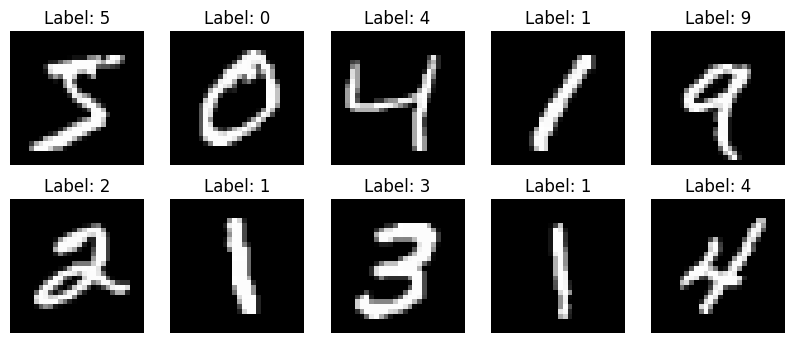

Epoch 1/50
750/750 [==============================] - 10s 12ms/step - loss: 0.2070 - accuracy: 0.9371 - val_loss: 0.0747 - val_accuracy: 0.9772
Epoch 2/50
750/750 [==============================] - 9s 12ms/step - loss: 0.0569 - accuracy: 0.9818 - val_loss: 0.0506 - val_accuracy: 0.9844
Epoch 3/50
750/750 [==============================] - 9s 12ms/step - loss: 0.0402 - accuracy: 0.9874 - val_loss: 0.0522 - val_accuracy: 0.9847
Epoch 4/50
750/750 [==============================] - 9s 12ms/step - loss: 0.0307 - accuracy: 0.9906 - val_loss: 0.0418 - val_accuracy: 0.9877
Epoch 5/50
750/750 [==============================] - 9s 12ms/step - loss: 0.0248 - accuracy: 0.9921 - val_loss: 0.0405 - val_accuracy: 0.9874
Epoch 6/50
750/750 [==============================] - 8s 11ms/step - loss: 0.0194 - accuracy: 0.9936 - val_loss: 0.0366 - val_accuracy: 0.9902
Epoch 7/50
750/750 [==============================] - 9s 12ms/step - loss: 0.0167 - accuracy: 0.9946 - val_loss: 0.0462 - val_accuracy: 0.988

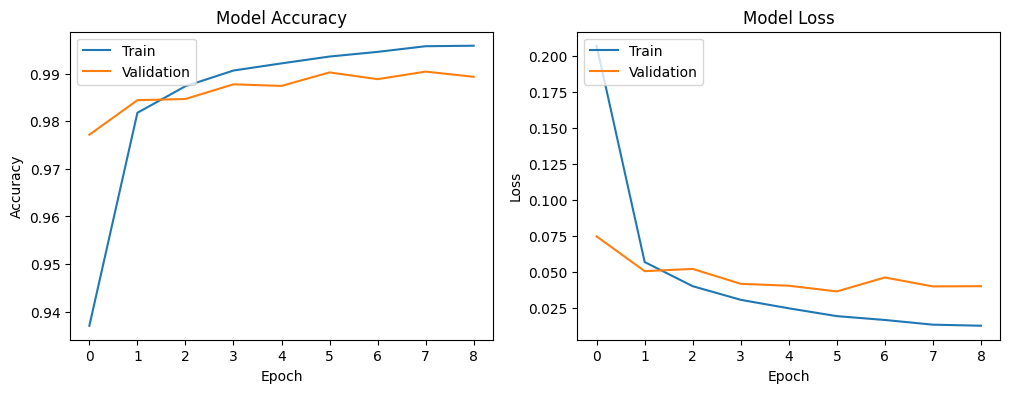

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def load_and_explore_dataset():
    # Step 1: Load and explore the MNIST dataset
    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()
    return train_images, train_labels, test_images, test_labels

def display_dataset_info(train_images):
    # Step 2: Display information about the dataset
    print(f"Number of training samples: {len(train_images)}")
    print(f"Shape of each image: {train_images[0].shape}")

def display_sample_images(train_images, train_labels):
    # Step 3: Display some sample images
    plt.figure(figsize=(10, 4))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(train_images[i], cmap='gray')
        plt.title(f"Label: {train_labels[i]}")
        plt.axis('off')
    plt.show()

def preprocess_data(train_images, test_images, train_labels, test_labels):
    # Step 4: Preprocess the data
    train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
    test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

    train_labels = tf.keras.utils.to_categorical(train_labels)
    test_labels = tf.keras.utils.to_categorical(test_labels)

    return train_images, test_images, train_labels, test_labels

def build_cnn_model():
    # Step 5: Build a CNN architecture
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

def compile_model(model):
    # Step 6: Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

def train_model(model, train_images, train_labels, early_stopping=True):
    # Step 7: Train the model with early stopping
    callbacks = []
    if early_stopping:
        early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        callbacks.append(early_stopping_callback)

    history = model.fit(train_images, train_labels, epochs=50, batch_size=64, validation_split=0.2, callbacks=callbacks)
    return history
    
def evaluate_model(model, test_images, test_labels):
    # Step 8: Evaluate the model on the test set
    test_loss, test_acc = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_acc}")

def save_model(model, filename='mnist_cnn_model.h5'):
    # Step 9: Save the trained model
    model.save(filename)

def plot_training_history(history):
    # Step 10: Plot the training history
    plt.figure(figsize=(12, 4))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

# Execute the steps
train_images, train_labels, test_images, test_labels = load_and_explore_dataset()
display_dataset_info(train_images)
display_sample_images(train_images, train_labels)
train_images, test_images, train_labels, test_labels = preprocess_data(train_images, test_images, train_labels, test_labels)
model = build_cnn_model()
compile_model(model)
history = train_model(model, train_images, train_labels, early_stopping=True)
evaluate_model(model, test_images, test_labels)
save_model(model)
plot_training_history(history)